In [9]:
import math
import random
from dataclasses import dataclass, field, fields
from itertools import count
from statistics import mean
from typing import Callable, Iterable, Collection, Generic, TypeVar, cast

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import data.cmudict as cmudict
from state_merging.algorithms.ostia import ostia
from state_merging.automata.SFST import SFST, run
from state_merging.collections.dense_int_dict import DenseIntDict
from state_merging.collections.dense_int_set import DenseIntSet
from state_merging.operations.learner import MergeResults
from state_merging.util import edit_distance

T = TypeVar('T')
T_ = TypeVar('T_')

random.seed(42)

In [10]:
@dataclass
class Results(Generic[T]):
    train_sample_count: T = field()
    train_sample_input_size: T = field()
    ptt_state_count: T = field()
    merged_state_count: T = field()
    state_compression: T = field()

    build_ptt_time: T = field()
    merge_states_time: T = field()

    test_sample_count: T = field()
    test_sample_output_size: T = field()
    word_error_count: T = field()
    char_error_count: T = field()

    @classmethod
    def from_merge_results(
            cls,
            merge_results: MergeResults,
    ) -> 'Results[float]':
        return Results(
            train_sample_count=merge_results.sample_count,
            train_sample_input_size=merge_results.sample_input_size,
            ptt_state_count=merge_results.ptt_state_count,
            merged_state_count=merge_results.merged_state_count,
            state_compression=1 - merge_results.merged_state_count/merge_results.ptt_state_count,
            build_ptt_time=merge_results.build_ptt_time,
            merge_states_time=merge_results.merge_states_time,
            test_sample_count=0.0,
            test_sample_output_size=0.0,
            word_error_count=0.0,
            char_error_count=0.0
        )

    @classmethod
    def accumulate_error_results(
        cls,
        results: 'Results[float]',
        fst: SFST[int, str, list[str]],
        test_dataset: Iterable[tuple[str, list[str]]]
    ) -> None:
        v_: list[str]
        for u, v in test_dataset:
            results.test_sample_count += 1
            results.test_sample_output_size += len(v)

            match run(fst, u, cast(list[str], []), lambda v1, v2: v1 + v2):
                case None:
                    v_ = []
                case _, out:
                    v_ = out

            if v != v_:
                results.word_error_count += 1

            results.char_error_count += edit_distance(
                v,
                v_,
                lambda _: 1,
                lambda _: 1,
                lambda c1, c2: 0 if c1 == c2 else 1
            )

    @classmethod
    def word_error_rate(cls, results: 'Results[float]') -> float:
        return results.word_error_count/results.test_sample_count

    @classmethod
    def char_error_rate(cls, results: 'Results[float]') -> float:
        return results.char_error_count/results.test_sample_output_size

    @classmethod
    def map(cls, fun: Callable[[T], T_], results: 'Results[T]') -> 'Results[T_]':
        return cls(**{
            f.name: fun(getattr(results, f.name))
            for f in fields(cls)
        }) # type: ignore

    @classmethod
    def collect(cls, all_results: Collection['Results[T]']) -> 'Results[list[T]]':
        return cls(**{
            f.name: [getattr(results, f.name) for results in all_results]
            for f in fields(cls)
        }) # type: ignore

    @classmethod
    def mean(cls, all_results: Collection['Results[float]']) -> 'Results[float]':
        return Results.map(mean, Results.collect(all_results)) # type: ignore

In [11]:
input_set: set[str] = cmudict.make_input_set()
output_set: set[str] = cmudict.make_output_set()
dataset: list[tuple[str, list[str]]] = list(cmudict.make_deterministic_sample())

print(
    f"loaded {len(dataset)} samples from the CMU Pronouncing Dictionary, e.g.:",
    random.choice(dataset)
)

print(f"input alphabet:", input_set)
print(f"output alphabet:", output_set)

loaded 126052 samples from the CMU Pronouncing Dictionary, e.g.: ('parmelee', ['P', 'AA1', 'R', 'M', 'IH0', 'L', 'IY0'])
input alphabet: {'w', 'o', 'n', 'p', '-', 'a', 't', "'", 'z', 'f', 'q', '.', 's', 'e', 'd', 'u', 'm', 'k', 'y', 'r', 'c', 'b', 'i', 'g', 'h', 'l', 'x', 'v', 'j'}
output alphabet: {'AO0', 'EY2', 'TH', 'DH', 'N', 'HH', 'EY0', 'JH', 'OW0', 'AE1', 'ZH', 'ER2', 'UH0', 'UW1', 'Y', 'D', 'OW1', 'L', 'SH', 'IY0', 'AH2', 'AO2', 'AA2', 'AH0', 'AO1', 'UW2', 'AY0', 'F', 'EH0', 'UH2', 'B', 'EH1', 'K', 'Z', 'W', 'P', 'OW2', 'NG', 'OY1', 'ER1', 'IY1', 'OY0', 'AA0', 'AA1', 'M', 'EH2', 'OY2', 'T', 'AY1', 'AW2', 'IH0', 'R', 'G', 'AW0', 'EY1', 'V', 'AH1', 'IH2', 'AE2', 'ER0', 'UW0', 'UH1', 'AE0', 'S', 'AY2', 'AW1', 'CH', 'IH1', 'IY2'}


In [12]:
iterations: int = 3
target_sample_sizes: list[int] = [int(10 ** (i / 4 + 2)) for i in range(5)]
test_sample_size = 10_000

random.shuffle(dataset)
test_dataset = dataset[:test_sample_size]
train_dataset = dataset[test_sample_size:]

print(
    f"to run {iterations} iterations of OSTIA with randomized merge order",
    f"on random samples of size {target_sample_sizes}"
)

to run 3 iterations of OSTIA with randomized merge order on random samples of size [100, 177, 316, 562, 1000]


In [13]:
mean_results_per_config: list[Results[float]] = []
mean_results_per_config_custom_dict: list[Results[float]] = []

for k in target_sample_sizes:
    print(f"running with sample size {k}")

    results_per_iter: list[Results[float]] = []
    results_per_iter_custom_dict: list[Results[float]] = []

    for i in range(iterations):
        print(i, end=' ')

        raw_fst, merge_results = ostia(
            input_set=input_set,
            dataset=random.sample(train_dataset, k=k),
            epsilon=[],
            concat=lambda v1, v2: cast(list[str], v1) + cast(list[str], v2),
            choose_transition=lambda _, trs: random.choice(list(trs)),
            search_iter=lambda _, qs: random.sample(list(qs), k=len(qs)),
            empty_state_set=set(),
            empty_transition_mapping={},
            empty_final_output_mapping={},
            make_empty_state_set=lambda _: set(),
            make_default_populated_mapping=lambda qs: {q: [] for q in qs},
            state_supply=count()
        )

        _, merge_results_custom_dict = ostia(
            input_set=input_set,
            dataset=random.sample(train_dataset, k=k),
            epsilon=[],
            concat=lambda v1, v2: cast(list[str], v1) + cast(list[str], v2),
            choose_transition=lambda _, trs: random.choice(list(trs)),
            search_iter=lambda _, qs: random.sample(list(qs), k=len(qs)),
            empty_state_set=DenseIntSet(),
            empty_transition_mapping={},
            empty_final_output_mapping=DenseIntDict(),
            make_empty_state_set=lambda qs: DenseIntSet(size=len(qs)),
            make_default_populated_mapping=lambda qs: DenseIntDict(size=len(qs), init=list),
            state_supply=count()
        )

        fst = cast(SFST[int, str, list[str]], raw_fst)
        results = Results.from_merge_results(merge_results)
        results_custom_dict = Results.from_merge_results(merge_results_custom_dict)

        Results.accumulate_error_results(results, fst, test_dataset)

        results_per_iter.append(results)
        results_per_iter_custom_dict.append(results_custom_dict)

    mean_results_per_config.append(Results.mean(results_per_iter))
    mean_results_per_config_custom_dict.append(Results.mean(results_per_iter_custom_dict))

    print()

print("done")

running with sample size 100
0 1 2 
running with sample size 177
0 1 2 
running with sample size 316
0 1 2 
running with sample size 562
0 1 2 
running with sample size 1000
0 1 2 
done


In [14]:
r: Results[list[float]] = Results.collect(mean_results_per_config) # type: ignore
rcd: Results[list[float]] = Results.collect(mean_results_per_config_custom_dict) # type: ignore
rs: list[Results[list[float]]] = [r, rcd]

alpha = 0.3
y_range_pad = 1.1

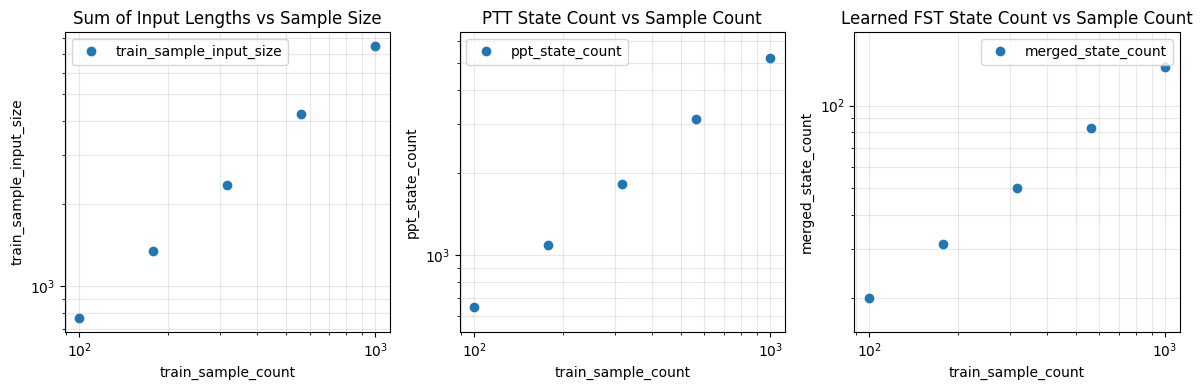

In [15]:
# type: ignore

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

y_log_datasets = [
    [math.log10(e) for e in r.train_sample_input_size],
    [math.log10(e) for e in r.ptt_state_count],
    [math.log10(e) for e in r.merged_state_count]
]

y_log_midpoints = [max(d)/2 + min(d)/2 for d in y_log_datasets]
y_log_ranges = [max(d) - min(d) for d in y_log_datasets]
y_log_range = max(y_log_ranges) * y_range_pad

axes[0].loglog(r.train_sample_count, r.train_sample_input_size, 'o', label='train_sample_input_size')
axes[0].set_title('Sum of Input Lengths vs Sample Size')
axes[0].set_xlabel('train_sample_count')
axes[0].set_ylabel('train_sample_input_size')

axes[1].loglog(r.train_sample_count, r.ptt_state_count, 'o', label='ppt_state_count')
axes[1].set_title('PTT State Count vs Sample Count')
axes[1].set_xlabel('train_sample_count')
axes[1].set_ylabel('ppt_state_count')

axes[2].loglog(r.train_sample_count, r.merged_state_count, 'o', label='merged_state_count')
axes[2].set_title('Learned FST State Count vs Sample Count')
axes[2].set_xlabel('train_sample_count')
axes[2].set_ylabel('merged_state_count')

for i in [0, 1, 2]:
    axes[i].set_ylim(
        10**(y_log_midpoints[i] - y_log_range/2),
        10**(y_log_midpoints[i] + y_log_range/2)
    )

    axes[i].grid(True, which='both', alpha=alpha)
    axes[i].legend()

plt.tight_layout()
plt.show()

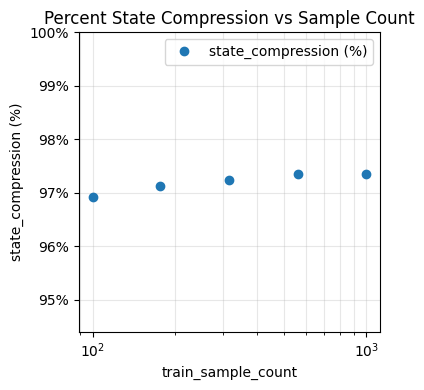

In [16]:
# type: ignore

fig, axes = plt.subplots(1, 1, figsize=(4, 4))

axes.semilogx(r.train_sample_count, [100 * e for e in r.state_compression], 'o', label='state_compression (%)')
axes.set_title('Percent State Compression vs Sample Count')
axes.set_xlabel('train_sample_count')
axes.set_ylabel('state_compression (%)')
axes.set_ylim(100 * (2*mean(r.state_compression) - 1), 100)
axes.yaxis.set_major_formatter(PercentFormatter(decimals=0))
axes.grid(True, which='both', alpha=alpha)
axes.legend()

plt.tight_layout()
plt.show()

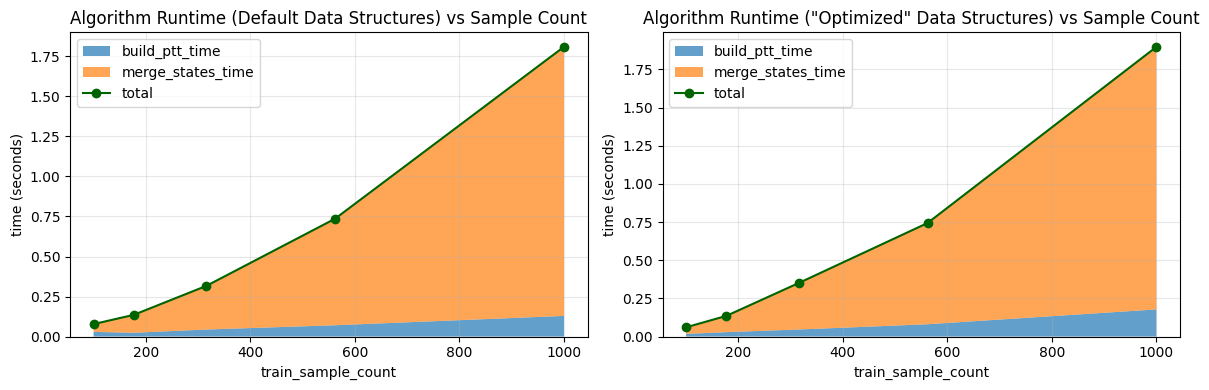

In [17]:
# type: ignore

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

titles = [
    'Algorithm Runtime (Default Data Structures) vs Sample Count',
    'Algorithm Runtime ("Optimized" Data Structures) vs Sample Count'
]

for i in range(len(rs)):

    axes[i].stackplot(
        rs[i].train_sample_count,
        rs[i].build_ptt_time,
        rs[i].merge_states_time,
        labels=['build_ptt_time', 'merge_states_time'],
        alpha=0.7
    )

    total_time = [
        b + m
        for b, m in zip(rs[i].build_ptt_time, rs[i].merge_states_time)
    ]

    axes[i].plot(r.train_sample_count, total_time, 'o-', color='darkgreen', label='total')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('train_sample_count')
    axes[i].set_ylabel('time (seconds)')
    axes[i].grid(True, which='both', alpha=alpha)
    axes[i].legend()

plt.tight_layout()
plt.show()

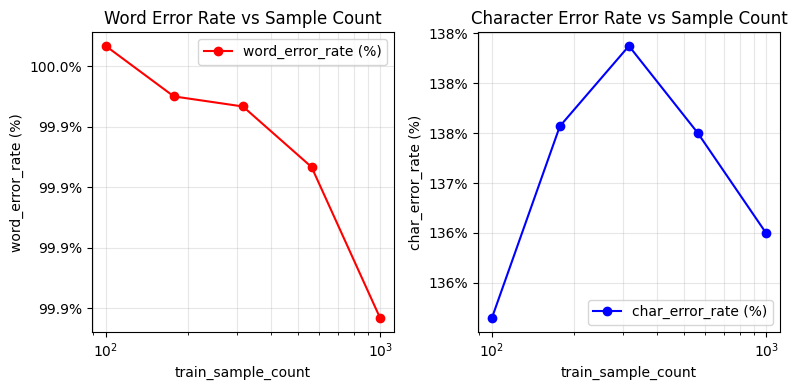

In [18]:
# type: ignore

word_error_rates = [Results.word_error_rate(result) for result in mean_results_per_config]
char_error_rates = [Results.char_error_rate(result) for result in mean_results_per_config]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].semilogx(r.train_sample_count, [100 * e for e in word_error_rates], 'o-', color='red')
axes[0].set_title('Word Error Rate vs Sample Count')
axes[0].set_xlabel('train_sample_count')
axes[0].set_ylabel('word_error_rate (%)')
axes[0].yaxis.set_major_formatter(PercentFormatter(decimals=1))
axes[0].grid(True, which='both', alpha=alpha)
axes[0].legend(['word_error_rate (%)'])

axes[1].semilogx(r.train_sample_count, [100 * e for e in char_error_rates], 'o-', color='blue')
axes[1].set_title('Character Error Rate vs Sample Count')
axes[1].set_xlabel('train_sample_count')
axes[1].set_ylabel('char_error_rate (%)')
axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))
axes[1].grid(True, which='both', alpha=alpha)
axes[1].legend(['char_error_rate (%)'])

plt.tight_layout()
plt.show()